# Swin Transformer

Also added:
- Grand-Cam (visualize which regions the modil focuses on)
- TTA (Run image through multiple augmentations, avg preds --> Free accuracy boost)
- Knowledge Distilation from MobileNetV2 after training base Swin first

NOTE: A lot is copied from the MobileNetV2 as configs, data prep and model prep stayed the same

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import Swin_S_Weights, Swin_T_Weights, MobileNet_V2_Weights
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from collections import Counter
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [4]:
DATA_ROOT = Path("../datasets/final")
TRAIN_DIR_CROPPED = DATA_ROOT / "train_cropped"
TEST_DIR_CROPPED  = DATA_ROOT / "test_cropped"

SEAL_CLASSES = ["bird", "boar", "dog", "dragon", "hare", "horse",
                "monkey", "ox", "ram", "rat", "snake", "tiger"]
CLASS_TO_IDX = {cls: i for i, cls in enumerate(SEAL_CLASSES)}

DEVICE     = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
BATCH_SIZE = 32     # smaller than MobileNetV2 run — Swin-S is heavier
LR         = 3e-4
LR_BACKBONE= 5e-5
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 30
PATIENCE      = 8
MIN_DELTA     = 0.005

# Switch to "swin_t" if Swin-S is too slow
SWIN_VARIANT = "swin_s"

print(f"Device: {DEVICE}")
print(f"Model:  {SWIN_VARIANT}")

Device: mps
Model:  swin_s


## Dataset and Dataloaders

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

class HandSealDataset(Dataset):
    def __init__(self, split_dir: Path, transform):
        self.samples  = []
        self.transform = transform
        for cls in SEAL_CLASSES:
            cls_dir = split_dir / cls
            if not cls_dir.is_dir():
                continue
            for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
                for img_path in cls_dir.glob(ext):
                    self.samples.append((img_path, CLASS_TO_IDX[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

In [8]:
train_dataset = HandSealDataset(TRAIN_DIR_CROPPED, train_transforms)
test_dataset  = HandSealDataset(TEST_DIR_CROPPED,  test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=False)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 4698 | Test: 757


## Swain Model

### Build

In [6]:
def build_swin(num_classes: int = 12, variant: str = "swin_s") -> nn.Module:
    if variant == "swin_s":
        model   = models.swin_s(weights=Swin_S_Weights.DEFAULT)
        in_feats = model.head.in_features   # 768
    else:
        model   = models.swin_t(weights=Swin_T_Weights.DEFAULT)
        in_feats = model.head.in_features   # 768

    # Freeze backbone
    for p in model.parameters():
        p.requires_grad = False

    # Replace head
    model.head = nn.Sequential(
        nn.LayerNorm(in_feats),
        nn.Dropout(p=0.4),
        nn.Linear(in_feats, 256),
        nn.GELU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    return model

model = build_swin(num_classes=len(SEAL_CLASSES), variant=SWIN_VARIANT).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} params")

Trainable: 201,484 / 49,038,742 params


### Helpers

In [9]:
counts  = Counter(label for _, label in train_dataset.samples)
total   = sum(counts.values())
weights = torch.tensor(
    [total / (len(SEAL_CLASSES) * max(counts.get(CLASS_TO_IDX[c], 1), 1))
     for c in SEAL_CLASSES],
    dtype=torch.float
).to(DEVICE)

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        pt   = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

criterion = FocalLoss(weight=weights, gamma=2.0)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)                              # ← single forward pass
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)
        correct    += (logits.argmax(1) == labels).sum().item()   # ← reuse logits
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits      = model(imgs)
        total_loss += criterion(logits, labels).item() * len(imgs)
        correct    += (logits.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

## Phase 1

In [7]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_PHASE1
)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Phase 1: Training head only")
for epoch in range(EPOCHS_PHASE1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = eval_epoch(model,  test_loader,  criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch+1:02d} | "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.3f} acc {va_acc:.3f}")

Phase 1: Training head only
Epoch 01 | train loss 1.504 acc 0.358 | val loss 0.950 acc 0.609
Epoch 02 | train loss 0.869 acc 0.589 | val loss 0.608 acc 0.736
Epoch 03 | train loss 0.704 acc 0.640 | val loss 0.527 acc 0.716
Epoch 04 | train loss 0.639 acc 0.675 | val loss 0.450 acc 0.777
Epoch 05 | train loss 0.595 acc 0.693 | val loss 0.425 acc 0.764
Epoch 06 | train loss 0.563 acc 0.699 | val loss 0.409 acc 0.781
Epoch 07 | train loss 0.549 acc 0.709 | val loss 0.388 acc 0.785
Epoch 08 | train loss 0.533 acc 0.712 | val loss 0.374 acc 0.799
Epoch 09 | train loss 0.536 acc 0.711 | val loss 0.369 acc 0.794
Epoch 10 | train loss 0.521 acc 0.718 | val loss 0.369 acc 0.795


## Phase 2

In [8]:
# Unfreeze last 2 Swin stages (stages 3 and 4 in model.features)
for layer in list(model.features.children())[-4:]:
    for p in layer.parameters():
        p.requires_grad = True

optimizer = torch.optim.AdamW([
    {"params": model.features.parameters(), "lr": LR_BACKBONE},
    {"params": model.head.parameters(),     "lr": LR}
])
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR_BACKBONE, LR],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_PHASE2,
    pct_start=0.3
)

best_val_acc     = 0
patience_counter = 0

print("Phase 2: Fine-tuning backbone")
for epoch in range(EPOCHS_PHASE2):
    model.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        criterion(model(imgs), labels).backward()
        optimizer.step()
        scheduler.step()

    tr_loss, tr_acc = eval_epoch(model, train_loader, criterion)
    va_loss, va_acc = eval_epoch(model, test_loader,  criterion)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    improved = va_acc > best_val_acc + MIN_DELTA
    if improved:
        best_val_acc     = va_acc
        patience_counter = 0
        torch.save(model.state_dict(), "swin_best.pth")
    else:
        patience_counter += 1

    print(f"Epoch {epoch+EPOCHS_PHASE1+1:02d} | "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.3f} acc {va_acc:.3f}"
          + (" ← best" if improved else f" (patience {patience_counter}/{PATIENCE})"))

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+EPOCHS_PHASE1+1}")
        break

print(f"\nBest val accuracy: {best_val_acc:.3f}")

Phase 2: Fine-tuning backbone
Epoch 11 | train loss 0.172 acc 0.905 | val loss 0.255 acc 0.847 ← best
Epoch 12 | train loss 0.119 acc 0.930 | val loss 0.166 acc 0.884 ← best
Epoch 13 | train loss 0.074 acc 0.952 | val loss 0.081 acc 0.938 ← best
Epoch 14 | train loss 0.041 acc 0.975 | val loss 0.051 acc 0.958 ← best
Epoch 15 | train loss 0.030 acc 0.980 | val loss 0.029 acc 0.979 ← best
Epoch 16 | train loss 0.020 acc 0.989 | val loss 0.014 acc 0.996 ← best
Epoch 17 | train loss 0.012 acc 0.990 | val loss 0.011 acc 0.995 (patience 1/8)
Epoch 18 | train loss 0.011 acc 0.992 | val loss 0.013 acc 0.992 (patience 2/8)
Epoch 19 | train loss 0.012 acc 0.990 | val loss 0.013 acc 0.992 (patience 3/8)
Epoch 20 | train loss 0.007 acc 0.994 | val loss 0.009 acc 0.996 (patience 4/8)
Epoch 21 | train loss 0.007 acc 0.995 | val loss 0.011 acc 0.996 (patience 5/8)
Epoch 22 | train loss 0.008 acc 0.993 | val loss 0.010 acc 0.993 (patience 6/8)
Epoch 23 | train loss 0.005 acc 0.996 | val loss 0.008 acc

## Analysis

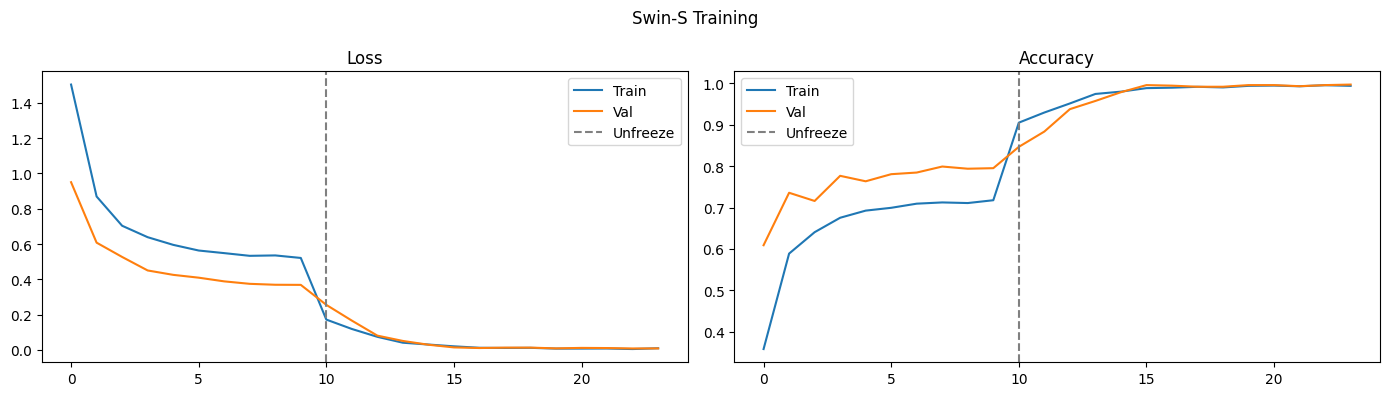

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.axvline(EPOCHS_PHASE1, color="gray", linestyle="--", label="Unfreeze")
ax1.set_title("Loss"); ax1.legend()

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"],   label="Val")
ax2.axvline(EPOCHS_PHASE1, color="gray", linestyle="--", label="Unfreeze")
ax2.set_title("Accuracy"); ax2.legend()

plt.suptitle(f"Swin-{'S' if SWIN_VARIANT == 'swin_s' else 'T'} Training")
plt.tight_layout()
plt.show()

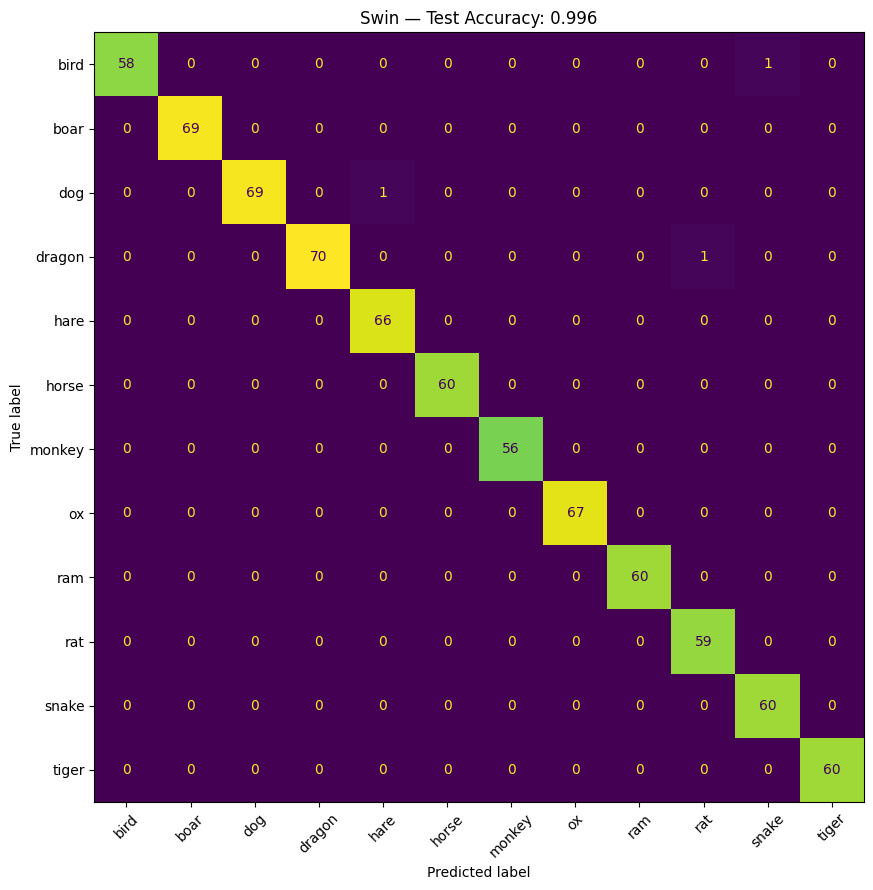

In [13]:
model.load_state_dict(torch.load("swin_best.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(cm, display_labels=SEAL_CLASSES).plot(
    ax=ax, colorbar=False, xticks_rotation=45
)
plt.title(f"Swin — Test Accuracy: {accuracy_score(all_labels, all_preds):.3f}")
plt.tight_layout()
plt.show()

### Grad-CAM

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_grad_cam/utils/svd_on_activations.py:17: RuntimeWarning: divide by zero encountered in matmul
  projection = reshaped_activations @ VT[0, :]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_grad_cam/utils/svd_on_activations.py:17: RuntimeWarning: overflow encountered in matmul
  projection = reshaped_activations @ VT[0, :]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_grad_cam/utils/svd_on_activations.py:17: RuntimeWarning: invalid value encountered in matmul
  projection = reshaped_activations @ VT[0, :]


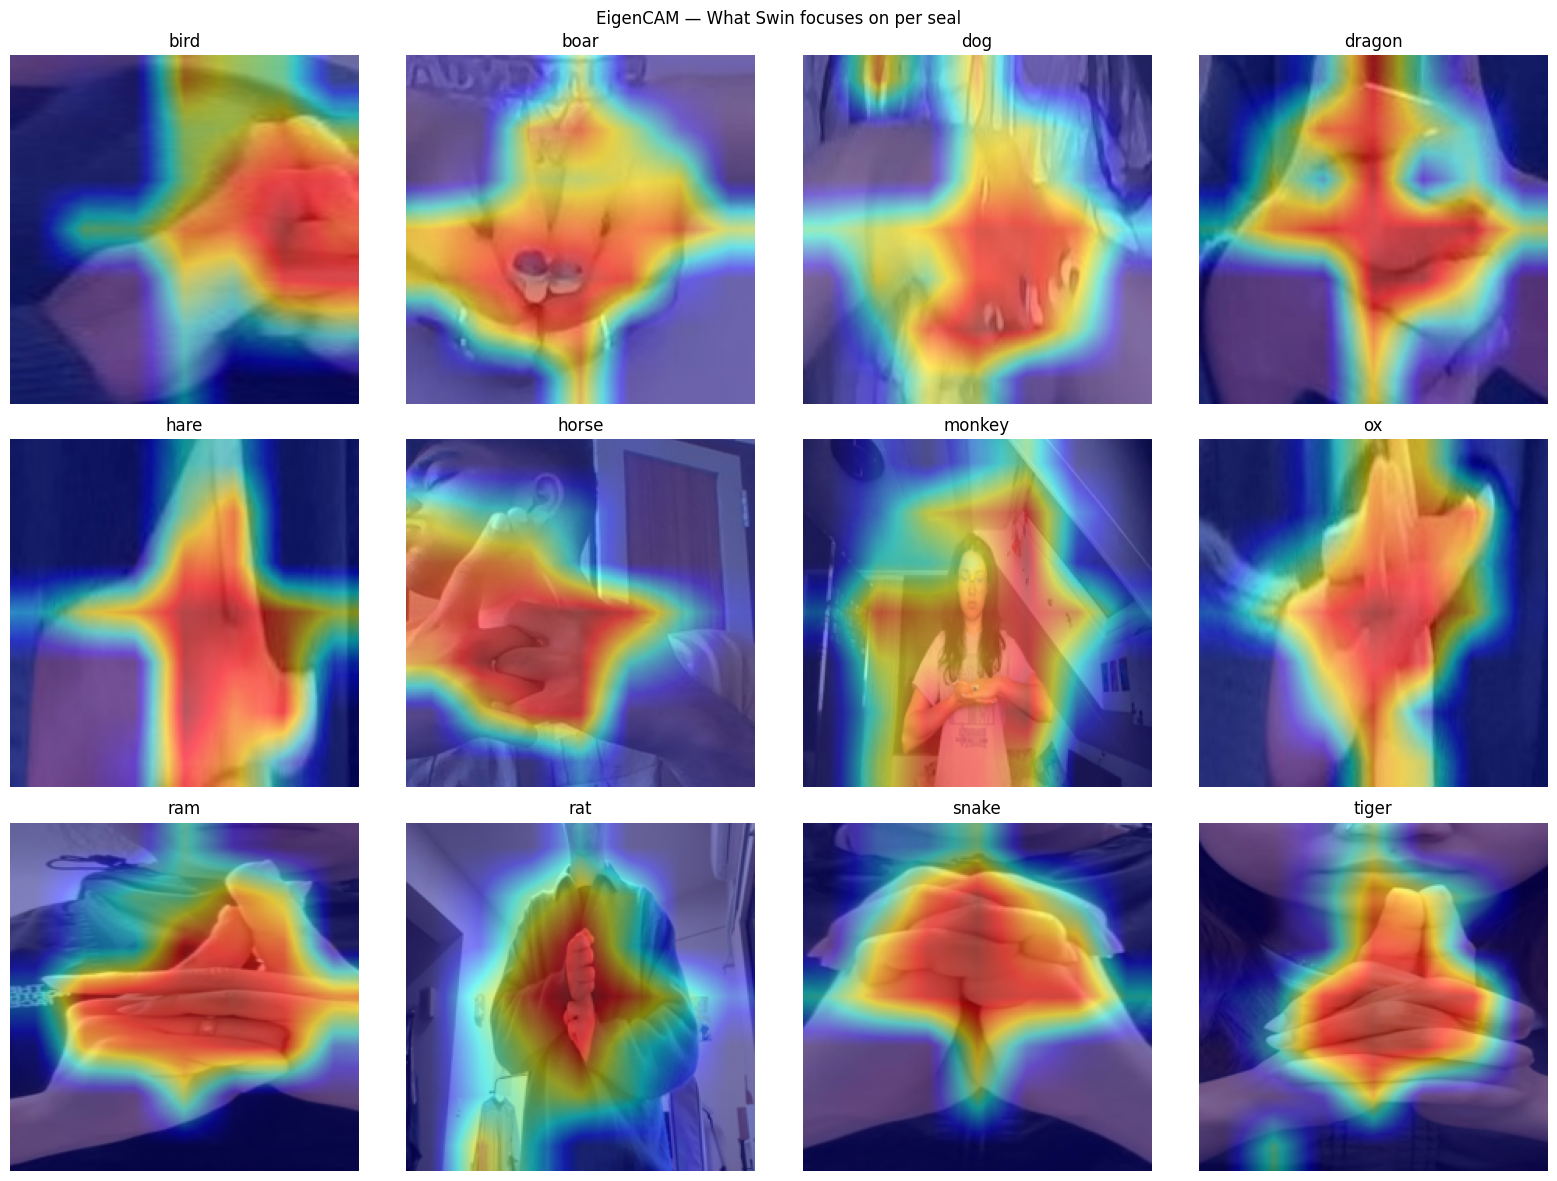

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
       

In [11]:
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

model.load_state_dict(torch.load("swin_best.pth", map_location=DEVICE))
model_cpu = model.cpu()
model_cpu.eval()

def reshape_transform(tensor):
    return tensor.permute(0, 3, 1, 2)  # (B, H, W, C) → (B, C, H, W)

cam = EigenCAM(
    model=model_cpu,
    target_layers=[model_cpu.features[-1][-1]],
    reshape_transform=reshape_transform
)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, cls in enumerate(SEAL_CLASSES):
    img_path = next((TEST_DIR_CROPPED / cls).glob("*.jpg"))
    img_pil  = Image.open(img_path).convert("RGB").resize((224, 224))
    img_np   = np.array(img_pil) / 255.0

    tensor = test_transforms(img_pil).unsqueeze(0)
    target = [ClassifierOutputTarget(CLASS_TO_IDX[cls])]

    grayscale_cam = cam(input_tensor=tensor, targets=target)[0]
    visualization = show_cam_on_image(img_np.astype(np.float32),
                                      grayscale_cam, use_rgb=True)

    ax = axes[i // 4][i % 4]
    ax.imshow(visualization)
    ax.set_title(cls)
    ax.axis("off")

plt.suptitle("EigenCAM — What Swin focuses on per seal")
plt.tight_layout()
plt.show()

model.to(DEVICE)

### TTA evaluation

- Instead of running each test image through the model once, you run it through multiple times with different augmentations applied, then average all the predictions together.

In [14]:
tta_transforms = [
    transforms.Compose([transforms.Resize((224, 224)),
                        transforms.ToTensor(),
                        transforms.Normalize([0.485, 0.456, 0.406],
                                             [0.229, 0.224, 0.225])]),
    transforms.Compose([transforms.Resize((256, 256)),
                        transforms.CenterCrop(224),
                        transforms.ToTensor(),
                        transforms.Normalize([0.485, 0.456, 0.406],
                                             [0.229, 0.224, 0.225])]),
    transforms.Compose([transforms.Resize((224, 224)),
                        transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(),
                        transforms.Normalize([0.485, 0.456, 0.406],
                                             [0.229, 0.224, 0.225])]),
    transforms.Compose([transforms.Resize((224, 224)),
                        transforms.RandomRotation(degrees=(10, 10)),
                        transforms.ToTensor(),
                        transforms.Normalize([0.485, 0.456, 0.406],
                                             [0.229, 0.224, 0.225])]),
    transforms.Compose([transforms.Resize((224, 224)),
                        transforms.RandomRotation(degrees=(-10, -10)),
                        transforms.ToTensor(),
                        transforms.Normalize([0.485, 0.456, 0.406],
                                             [0.229, 0.224, 0.225])]),
]

model.eval()
all_labels_tta, all_preds_tta = [], []

for img_path, label in test_dataset.samples:
    img     = Image.open(img_path).convert("RGB")
    avg_prob = torch.zeros(len(SEAL_CLASSES)).to(DEVICE)

    with torch.no_grad():
        for t in tta_transforms:
            tensor   = t(img).unsqueeze(0).to(DEVICE)
            avg_prob += F.softmax(model(tensor), dim=1).squeeze()

    all_preds_tta.append(avg_prob.argmax().item())
    all_labels_tta.append(label)

tta_acc  = accuracy_score(all_labels_tta, all_preds_tta)
base_acc = accuracy_score(all_labels, all_preds)
print(f"Base accuracy: {base_acc:.3f}")
print(f"TTA  accuracy: {tta_acc:.3f}  (+{(tta_acc - base_acc)*100:.2f}%)")

Base accuracy: 0.996
TTA  accuracy: 0.996  (+0.00%)


## Comparison MobileNetv2 vs. Swin

In [15]:
# Load Swin results (already computed above as base_acc/tta_acc)
# Load MobileNetV2 for comparison
def build_mobilenet(num_classes):
    m = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.5), nn.Linear(in_f, 256),
        nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_classes)
    )
    return m

mobilenet = build_mobilenet(num_classes=len(SEAL_CLASSES))
mobilenet.load_state_dict(torch.load("mobilenetv2_best.pth", map_location=DEVICE))
mobilenet.to(DEVICE).eval()

mobilenet_preds, mobilenet_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = mobilenet(imgs.to(DEVICE)).argmax(1).cpu()
        mobilenet_preds.extend(preds.tolist())
        mobilenet_labels.extend(labels.tolist())
mobilenet_acc = accuracy_score(mobilenet_labels, mobilenet_preds)

print("=" * 50)
print(f"{'Model':<30} {'Test Acc':>10}")
print("=" * 50)
print(f"{'MobileNetV2':<30} {mobilenet_acc:>10.3f}")
print(f"{'Swin-S':<30} {base_acc:>10.3f}")
print(f"{'Swin-S + TTA':<30} {tta_acc:>10.3f}")
print("=" * 50)

Model                            Test Acc
MobileNetV2                         0.984
Swin-S                              0.996
Swin-S + TTA                        0.996


## Knowledge Distillation

In [ ]:
# ── load teacher (whichever checkpoint is best) ───────────────────────────────
# Change this path to mobilenetv2_best.pth if MobileNetV2 was better
TEACHER_CHECKPOINT = "swin_best.pth"

def build_mobilenet(num_classes):
    m = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.5), nn.Linear(in_f, 256),
        nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_classes)
    )
    return m

teacher = build_swin(num_classes=len(SEAL_CLASSES), variant=SWIN_VARIANT)
teacher.load_state_dict(torch.load(TEACHER_CHECKPOINT, map_location=DEVICE))
teacher.to(DEVICE).eval()
for p in teacher.parameters():
    p.requires_grad = False

student = build_mobilenet(num_classes=len(SEAL_CLASSES)).to(DEVICE)

# ── distillation loss ─────────────────────────────────────────────────────────
TEMPERATURE = 4.0   # soften teacher's distribution
ALPHA       = 0.7   # weight for soft labels vs hard labels

def distillation_loss(student_logits, teacher_logits, true_labels):
    soft_loss = F.kl_div(
        F.log_softmax(student_logits / TEMPERATURE, dim=1),
        F.softmax(teacher_logits    / TEMPERATURE, dim=1),
        reduction="batchmean"
    ) * (TEMPERATURE ** 2)
    hard_loss = F.cross_entropy(student_logits, true_labels)
    return ALPHA * soft_loss + (1 - ALPHA) * hard_loss

# ── train student ─────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(student.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

best_student_acc = 0
print("Training student via Knowledge Distillation")

for epoch in range(20):
    student.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.no_grad():
            teacher_logits = teacher(imgs)
        student_logits = student(imgs)
        loss = distillation_loss(student_logits, teacher_logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    scheduler.step()

    _, va_acc = eval_epoch(student, test_loader, criterion)
    if va_acc > best_student_acc:
        best_student_acc = va_acc
        torch.save(student.state_dict(), "student_best.pth")

    print(f"Epoch {epoch+1:02d} | val acc {va_acc:.3f}"
          + (" ← best" if va_acc == best_student_acc else ""))

print(f"\nBest student val accuracy: {best_student_acc:.3f}")